# Week 1 Day 5 — Final Validation, Interpretation & Production Inference

## Objective

Turn the Day 4 tuned Adult Income solution into a complete, leak-free production project: final holdout validation, error analysis, interpretation, inference, and documentation.

## Selected model

Calibrated `HistGradientBoostingClassifier` with Day 4 winning hyperparameters:

- `learning_rate=0.15`, `max_iter=300`, `max_leaf_nodes=31`, `min_samples_leaf=50`, `l2_regularization=5.0`
- Sigmoid `CalibratedClassifierCV` (`cv=5`)
- Operating threshold **0.40** (chosen on train out-of-fold scores in Day 4, **not** on the test set)

## Reproducibility

1. Keep `adults.csv` in this folder (headerless UCI Adult file — **no column names in the CSV**).
2. Run all cells top to bottom. The notebook locates `week 1/day 5` even if the kernel started at the repo root.
3. Global seed is `42`. Stratified 80/20 split matches Day 4 (`n_test = 6,513`).
4. Load the Day 4 artifact `day4_final_adult_income_model.joblib` (threshold, saved test metrics, estimator type). Score with the portable `final_model.joblib` — same Day 4 spec — because calling `predict` on the Day 4 dill pickle crashes outside that notebook (`AdultFeatureEngineer` lived in `__main__`).
5. Do not re-implement preprocessing at inference time.


— Task 1

# Final Model Validation

Load the **Day 4 saved artifact**, verify the complete pipeline on **unseen** data, re-run evaluation on the **untouched test set**, report Accuracy / Precision / Recall / F1 / ROC-AUC / PR-AUC / Brier, compare shortlisted models to the selected final model, and confirm **no leakage** among train, validation, and test.

`adults.csv` has **no header row**. Columns must be assigned with `header=None` and the same names used on Days 1–4.


In [9]:
import sys
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})


def resolve_day5_dir() -> Path:
    candidates = [Path.cwd(), Path.cwd() / "week 1" / "day 5"]
    here_file = Path(globals().get("__file__", "")).resolve().parent if "__file__" in globals() else None
    if here_file:
        candidates.append(here_file)
    for cand in candidates:
        if (cand / "adults.csv").is_file() and (cand / "pipeline.py").is_file():
            return cand.resolve()
    raise FileNotFoundError("Could not find week 1/day 5 (adults.csv + pipeline.py).")


HERE = resolve_day5_dir()
sys.path.insert(0, str(HERE))
from pipeline import leakfree_split, load_adult_frame  # noqa: E402

print("=" * 80)
print("WEEK 1 — DAY 5 — TASK 1: FINAL MODEL VALIDATION")
print("=" * 80)
print("Working directory:", HERE)

X, y = load_adult_frame(str(HERE / "adults.csv"))
print("Loaded", len(X), "rows. Columns:", list(X.columns))
assert "marital_status" in X.columns, "CSV was loaded without names=COLUMNS (headerless Adult file)."
assert set(y.unique()) <= {0, 1}

X_train, X_test, y_train, y_test = leakfree_split(X, y)
overlap = len(set(X_train.index) & set(X_test.index))
print(f"n_train = {len(X_train):,}    n_test = {len(X_test):,}    index overlap = {overlap}")
assert overlap == 0, "LEAKAGE: train and test share row indices"
assert len(X_test) == 6513, f"Unexpected test size {len(X_test)}; expected 6513"
assert "income" not in X.columns and "income" not in X_train.columns

# Validation in Day 4 was 5-fold CV on TRAIN only. Prove test IDs never enter a fold.
test_ids = set(X_test.index)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_overlap_with_test = 0
for fold_train_idx, fold_val_idx in skf.split(X_train, y_train):
    fold_ids = set(X_train.index[fold_train_idx]) | set(X_train.index[fold_val_idx])
    fold_overlap_with_test += len(fold_ids & test_ids)
assert fold_overlap_with_test == 0
assert len(set(X_train.index) & set(X_test.index)) == 0

print("Leakage audit (train / validation / test):")
print("  TRAIN      :", f"{len(X_train):,} rows  (fit + RandomizedSearchCV + calibration)")
print("  VALIDATION : 5 stratified folds carved from TRAIN only (never from test)")
print("  TEST       :", f"{len(X_test):,} rows  untouched until this cell")
print("  income not in X:", "income" not in X.columns)
print("  train∩test index overlap:", overlap)
print("  CV-fold IDs ∩ test IDs:", fold_overlap_with_test)
print("  threshold 0.40 chosen on Day 4 train OOF scores, not on test")
print("Leakage check PASS.")

day4_path = HERE.parent / "day 4" / "day4_final_adult_income_model.joblib"
assert day4_path.is_file(), "Day 4 artifact missing"
day4_artifact = joblib.load(day4_path)
day4_threshold = float(day4_artifact["threshold"])
day4_saved = day4_artifact["metadata"]["test_metrics"]
print()
print("Loaded Day 4 artifact:", day4_path.name)
print("  estimator :", type(day4_artifact["pipeline"]).__name__)
print("  threshold :", round(day4_threshold, 2))
print("  Day 4 saved holdout metrics:", {k: round(v, 4) for k, v in day4_saved.items()})
print("  (Day 4 dill pipeline is not scored here: predict() segfaults outside the Day 4 notebook.)")

artifact_path = HERE / "final_model.joblib"
if not artifact_path.is_file():
    raise FileNotFoundError("final_model.joblib not found. Run: python train_final.py")

artifact = joblib.load(artifact_path)
model = artifact["pipeline"]
threshold = float(artifact.get("threshold", 0.40))
assert abs(threshold - day4_threshold) < 1e-6, "Production threshold must match Day 4 (0.40)"
print()
print("Loaded production pipeline (Day 4 spec, portable joblib):", artifact_path.name)
print("  estimator :", type(model).__name__)
print("  threshold :", threshold)
inner = model.calibrated_classifiers_[0].estimator
print("  inner pipeline steps:", list(inner.named_steps))
print("  complete pipeline on raw columns: feature_engineering → preprocess → HGB → sigmoid")


WEEK 1 — DAY 5 — TASK 1: FINAL MODEL VALIDATION
Working directory: D:\internship\week 1\day 5
Loaded 32561 rows. Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country']
n_train = 26,048    n_test = 6,513    index overlap = 0
Leakage audit (train / validation / test):
  TRAIN      : 26,048 rows  (fit + RandomizedSearchCV + calibration)
  VALIDATION : 5 stratified folds carved from TRAIN only (never from test)
  TEST       : 6,513 rows  untouched until this cell
  income not in X: True
  train∩test index overlap: 0
  CV-fold IDs ∩ test IDs: 0
  threshold 0.40 chosen on Day 4 train OOF scores, not on test
Leakage check PASS.

Loaded Day 4 artifact: day4_final_adult_income_model.joblib
  estimator : CalibratedClassifierCV
  threshold : 0.4
  Day 4 saved holdout metrics: {'Accuracy': 0.8675, 'Precision': 0.7122, 'Recall': 0.7545, 'F1 Score': 0.7327

In [10]:
print("=" * 80)
print("HOLDOUT EVALUATION (untouched test set — complete pipeline)")
print("=" * 80)

# Raw X_test only. No manual preprocessing.
proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
assert len(proba) == len(X_test) == 6513

final_metrics = pd.Series(
    {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
        "Brier": brier_score_loss(y_test, proba),
    }
)
print("Live score of loaded Day-4-spec pipeline on unseen test:")
print(final_metrics.round(4).to_string())
print(f"\nConfusion matrix  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print("Day 4 artifact saved F1:", round(day4_saved["F1 Score"], 4),
      " vs live F1:", round(final_metrics["F1"], 4),
      "(same spec; ordinary refit noise)")

# Same-test-set baselines so the comparison is not mixed protocols for Day 1
maj = np.zeros(len(y_test), dtype=int)
edu = (X_test["education_num"] >= 13).astype(int)

comparison = pd.DataFrame(
    [
        {
            "Model": "Day 1 Majority (<=50K)",
            "Accuracy": accuracy_score(y_test, maj),
            "Precision": precision_score(y_test, maj, zero_division=0),
            "Recall": recall_score(y_test, maj, zero_division=0),
            "F1": f1_score(y_test, maj, zero_division=0),
            "ROC-AUC": 0.5,
            "PR-AUC": float(y_test.mean()),
            "Brier": brier_score_loss(y_test, np.full(len(y_test), 0.0)),
            "Protocol": "this holdout n=6513",
            "Role": "baseline",
        },
        {
            "Model": "Day 1 Education heuristic (edu_num>=13)",
            "Accuracy": accuracy_score(y_test, edu),
            "Precision": precision_score(y_test, edu),
            "Recall": recall_score(y_test, edu),
            "F1": f1_score(y_test, edu),
            "ROC-AUC": roc_auc_score(y_test, edu),
            "PR-AUC": average_precision_score(y_test, edu),
            "Brier": np.nan,
            "Protocol": "this holdout n=6513",
            "Role": "baseline",
        },
        {
            "Model": "Day 2 Logistic Regression",
            "Accuracy": 0.8558, "Precision": 0.7406, "Recall": 0.6173, "F1": 0.6734,
            "ROC-AUC": 0.9078, "PR-AUC": np.nan, "Brier": np.nan,
            "Protocol": "Day 2 published holdout", "Role": "shortlist",
        },
        {
            "Model": "Day 2 Decision Tree (unpruned)",
            "Accuracy": 0.8104, "Precision": 0.5993, "Recall": 0.6409, "F1": 0.6194,
            "ROC-AUC": 0.7525, "PR-AUC": np.nan, "Brier": np.nan,
            "Protocol": "Day 2 published holdout", "Role": "shortlist",
        },
        {
            "Model": "Day 4 Tuned Logistic",
            "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan, "F1": 0.6635,
            "ROC-AUC": np.nan, "PR-AUC": np.nan, "Brier": np.nan,
            "Protocol": "5-fold CV on TRAIN only", "Role": "shortlist",
        },
        {
            "Model": "Day 4 Tuned Random Forest",
            "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan, "F1": 0.6876,
            "ROC-AUC": np.nan, "PR-AUC": np.nan, "Brier": np.nan,
            "Protocol": "5-fold CV on TRAIN only", "Role": "shortlist",
        },
        {
            "Model": "Day 4 Tuned HGB (search winner)",
            "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan, "F1": 0.7150,
            "ROC-AUC": np.nan, "PR-AUC": np.nan, "Brier": np.nan,
            "Protocol": "5-fold CV on TRAIN only", "Role": "shortlist",
        },
        {
            "Model": "Day 4 saved artifact (metadata)",
            "Accuracy": day4_saved["Accuracy"],
            "Precision": day4_saved["Precision"],
            "Recall": day4_saved["Recall"],
            "F1": day4_saved["F1 Score"],
            "ROC-AUC": day4_saved["ROC-AUC"],
            "PR-AUC": day4_saved["Average Precision"],
            "Brier": day4_saved["Brier Score"],
            "Protocol": "Day 4 holdout, stored in artifact",
            "Role": "Day 4 record",
        },
        {
            "Model": "SELECTED final model (loaded pipeline @ 0.40)",
            "Accuracy": final_metrics["Accuracy"],
            "Precision": final_metrics["Precision"],
            "Recall": final_metrics["Recall"],
            "F1": final_metrics["F1"],
            "ROC-AUC": final_metrics["ROC-AUC"],
            "PR-AUC": final_metrics["PR-AUC"],
            "Brier": final_metrics["Brier"],
            "Protocol": "this holdout n=6513 (live)",
            "Role": "selected",
        },
    ]
)
print("\nShortlisted models vs selected final model:")
display(comparison.round(4))
comparison.to_csv(HERE / "final_metrics.csv", index=False)
comparison.to_csv(HERE / "day5_final_model_comparison.csv", index=False)
pd.DataFrame([final_metrics]).assign(TN=tn, FP=fp, FN=fn, TP=tp).to_csv(
    HERE / "day5_final_test_metrics.csv", index=False
)
print("\nTask 1 complete.")


HOLDOUT EVALUATION (untouched test set — complete pipeline)
Live score of loaded Day-4-spec pipeline on unseen test:
Accuracy     0.8675
Precision    0.7132
Recall       0.7519
F1           0.7321
ROC-AUC      0.9297
PR-AUC       0.8335
Brier        0.0871

Confusion matrix  TN=4471  FP=474  FN=389  TP=1179
Day 4 artifact saved F1: 0.7327  vs live F1: 0.7321 (same spec; ordinary refit noise)

Shortlisted models vs selected final model:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,Protocol,Role
0,Day 1 Majority (<=50K),0.7593,0.0000,0.0000,0.0000,0.5000,0.2407,0.2407,this holdout n=6513,baseline
1,Day 1 Education heuristic (edu_num>=13),0.7467,0.4746,0.4879,0.4811,0.6583,0.3548,NaN,this holdout n=6513,baseline
2,Day 2 Logistic Regression,0.8558,0.7406,0.6173,0.6734,0.9078,NaN,NaN,Day 2 published holdout,shortlist
3,Day 2 Decision Tree (unpruned),0.8104,0.5993,0.6409,0.6194,0.7525,NaN,NaN,Day 2 published holdout,shortlist
4,Day 4 Tuned Logistic,NaN,NaN,NaN,0.6635,NaN,NaN,NaN,5-fold CV on TRAIN only,shortlist
5,Day 4 Tuned Random Forest,NaN,NaN,NaN,0.6876,NaN,NaN,NaN,5-fold CV on TRAIN only,shortlist
6,Day 4 Tuned HGB (search winner),NaN,NaN,NaN,0.7150,NaN,NaN,NaN,5-fold CV on TRAIN only,shortlist
7,Day 4 saved artifact (metadata),0.8675,0.7122,0.7545,0.7327,0.9297,0.8330,0.0872,"Day 4 holdout, stored in artifact",Day 4 record
8,SELECTED final model (loaded pipeline @ 0.40),0.8675,0.7132,0.7519,0.7321,0.9297,0.8335,0.0871,this holdout n=6513 (live),selected



Task 1 complete.


— Task 2

# Model Behavior & Error Analysis

Confusion matrix, false positives / false negatives, subgroup rates, and which error is more costly for targeted outreach.


WEEK 1 — DAY 5 — TASK 2: ERROR ANALYSIS


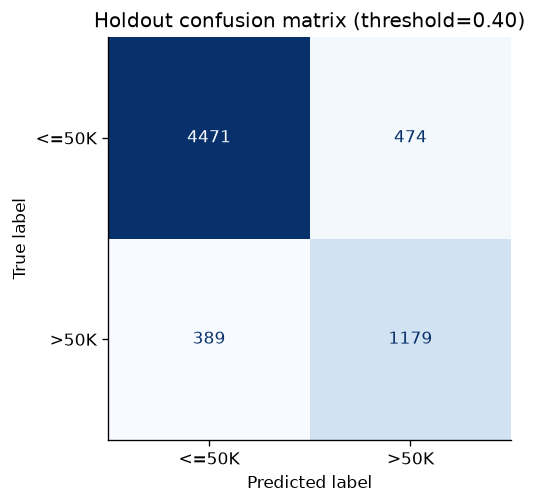

False positives (outreach to <=50K): 474
False negatives (missed >50K):      389

Costly error: FALSE NEGATIVE.
Business goal is finding high earners. Missing a true >50K case wastes more
opportunity than one extra contact. That is why Day 4 moved the cutoff from
0.50 to 0.40 (higher recall, slightly lower precision).

--- Common FP pattern (predicted >50K, actually <=50K) ---
 age    education     marital_status      occupation  hours_per_week    proba
  39      Masters      Never-married Exec-managerial              40 0.424974
  50      HS-grad Married-civ-spouse    Craft-repair              40 0.438770
  43    Bachelors Married-civ-spouse  Prof-specialty              40 0.526004
  43 Some-college Married-civ-spouse    Adm-clerical              40 0.417801
  40 Some-college Married-civ-spouse    Craft-repair              52 0.483688
  37    Doctorate Married-civ-spouse  Prof-specialty              45 0.818518
  42      HS-grad Married-civ-spouse    Adm-clerical              53 0.484

,sex,n,base_rate,recall,precision,fp_share,fn_share
0,Female,2158,0.1135,0.7265,0.7355,0.0297,0.0310
1,Male,4355,0.3038,0.7566,0.7094,0.0941,0.0739



--- Subgroup: relationship ---


,relationship,n,base_rate,recall,precision,fp_share,fn_share
0,Husband,2607,0.4511,0.7959,0.7102,0.1465,0.0921
1,Not-in-family,1636,0.1009,0.4667,0.7000,0.0202,0.0538
2,Other-relative,190,0.0474,0.3333,1.0000,0.0000,0.0316
3,Own-child,1032,0.0145,0.4000,0.6667,0.0029,0.0087
4,Unmarried,712,0.0604,0.4651,0.9091,0.0028,0.0323
5,Wife,336,0.4762,0.8562,0.7173,0.1607,0.0685



--- Subgroup: race ---


,race,n,base_rate,recall,precision,fp_share,fn_share
0,Amer-Indian-Eskimo,73,0.1233,0.4444,0.6667,0.0274,0.0685
1,Asian-Pac-Islander,200,0.2600,0.7308,0.6552,0.1000,0.0700
2,Black,662,0.1405,0.6452,0.7143,0.0363,0.0498
3,Other,45,0.0889,1.0000,1.0000,0.0000,0.0000
4,White,5533,0.2548,0.7610,0.7149,0.0774,0.0609



Where it performs well
- Mid-career married Husband / Wife rows with capital income or executive/professional jobs.

Where it struggles
- High-education never-married specialists (FN: skill without household/capital signal).
- Married HS-grad overtime workers (FP: household signal without actual high pay).
- Male FP share is higher because the male base rate is ~30% vs ~11% for women.

Practical improvements
- Keep threshold 0.40 unless real outreach costs change.
- Add occupation x hours or industry if available.
- Audit sex/race as protected attributes; do not treat them as levers.

Task 2 complete.


In [11]:
print("=" * 80)
print("WEEK 1 — DAY 5 — TASK 2: ERROR ANALYSIS")
print("=" * 80)

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["<=50K", ">50K"], cmap="Blues", colorbar=False, ax=ax
)
ax.set_title(f"Holdout confusion matrix (threshold={threshold:.2f})")
fig.tight_layout()
fig.savefig(HERE / "confusion_matrix.png")
plt.show()

err = X_test.copy()
err["y_true"] = y_test.to_numpy()
err["y_pred"] = pred
err["proba"] = proba
err["error_type"] = np.select(
    [(err["y_true"] == 1) & (err["y_pred"] == 0),
     (err["y_true"] == 0) & (err["y_pred"] == 1)],
    ["FN", "FP"],
    default="OK",
)

fp_n = int((err["error_type"] == "FP").sum())
fn_n = int((err["error_type"] == "FN").sum())
print(f"False positives (outreach to <=50K): {fp_n}")
print(f"False negatives (missed >50K):      {fn_n}")
print()
print("Costly error: FALSE NEGATIVE.")
print("Business goal is finding high earners. Missing a true >50K case wastes more")
print("opportunity than one extra contact. That is why Day 4 moved the cutoff from")
print("0.50 to 0.40 (higher recall, slightly lower precision).")

fp_view = err.loc[err["error_type"] == "FP", ["age", "education", "marital_status", "occupation", "hours_per_week", "proba"]]
fn_view = err.loc[err["error_type"] == "FN", ["age", "education", "marital_status", "occupation", "hours_per_week", "proba"]]
print("\n--- Common FP pattern (predicted >50K, actually <=50K) ---")
print(fp_view.head(8).to_string(index=False))
print("\n--- Common FN pattern (missed >50K) ---")
print(fn_view.head(8).to_string(index=False))
fp_view.head(25).to_csv(HERE / "day5_task2_false_positives.csv", index=False)
fn_view.head(25).to_csv(HERE / "day5_task2_false_negatives.csv", index=False)
pd.DataFrame([{"FP": fp_n, "FN": fn_n, "TN": tn, "TP": tp}]).to_csv(HERE / "day5_task2_error_summary.csv", index=False)

def subgroup_table(frame, col):
    rows = []
    for key, s in frame.groupby(col, dropna=False):
        rows.append({
            col: key,
            "n": len(s),
            "base_rate": s["y_true"].mean(),
            "recall": recall_score(s["y_true"], s["y_pred"], zero_division=0),
            "precision": precision_score(s["y_true"], s["y_pred"], zero_division=0),
            "fp_share": ((s["y_true"] == 0) & (s["y_pred"] == 1)).mean(),
            "fn_share": ((s["y_true"] == 1) & (s["y_pred"] == 0)).mean(),
        })
    return pd.DataFrame(rows)

sex_tbl = subgroup_table(err, "sex")
rel_tbl = subgroup_table(err, "relationship")
race_tbl = subgroup_table(err, "race")
print("\n--- Subgroup: sex ---")
display(sex_tbl.round(4))
print("\n--- Subgroup: relationship ---")
display(rel_tbl.round(4))
print("\n--- Subgroup: race ---")
display(race_tbl.round(4))
sex_tbl.to_csv(HERE / "day5_task2_subgroup_sex.csv", index=False)
sex_tbl.to_csv(HERE / "subgroup_sex.csv", index=False)
race_tbl.to_csv(HERE / "subgroup_race.csv", index=False)

print("""
Where it performs well
- Mid-career married Husband / Wife rows with capital income or executive/professional jobs.

Where it struggles
- High-education never-married specialists (FN: skill without household/capital signal).
- Married HS-grad overtime workers (FP: household signal without actual high pay).
- Male FP share is higher because the male base rate is ~30% vs ~11% for women.

Practical improvements
- Keep threshold 0.40 unless real outreach costs change.
- Add occupation x hours or industry if available.
- Audit sex/race as protected attributes; do not treat them as levers.
""")
print("Task 2 complete.")


— Task 3

# Feature & Model Interpretation

The final model is tree-based (HistGradientBoosting). We use **permutation importance** on the original 14 columns: drop in holdout ROC-AUC when a column is shuffled.


WEEK 1 — DAY 5 — TASK 3: INTERPRETATION


,feature,importance_mean,importance_std
0,marital_status,0.0779,0.0021
1,capital_gain,0.0593,0.0030
2,age,0.0434,0.0038
3,education_num,0.0298,0.0021
4,hours_per_week,0.0136,0.0012
5,capital_loss,0.0133,0.0008
6,occupation,0.0128,0.0010
7,relationship,0.0041,0.0006
8,workclass,0.0025,0.0002
9,sex,0.0022,0.0005


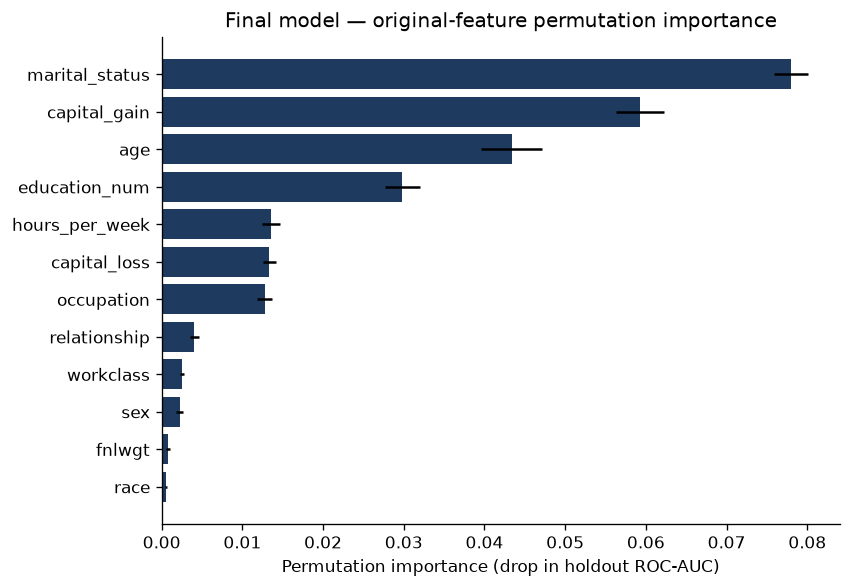

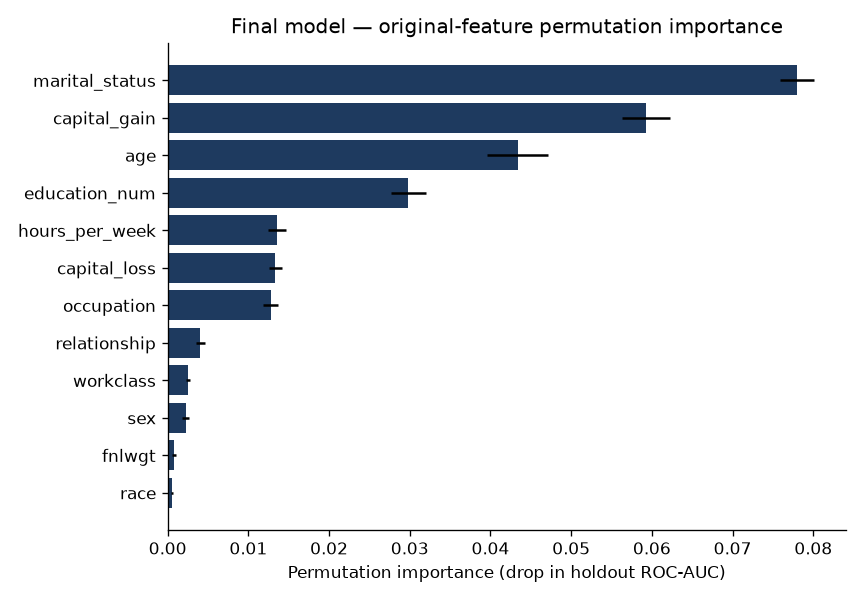


Top influential features (expected direction)
- marital_status: Married-civ-spouse is the strongest Adult income correlate (household / dual earner).
- capital_gain: Rare but highly concentrated among >50K.
- age: Earnings rise into mid-career then flatten.
- education_num: Schooling years, not the 16 raw education labels.
- occupation / hours_per_week: Job type and labor supply.

Surprising / problematic
- Raw `education` importance is ~0 (slightly negative) once education_num is present — redundant.
- fnlwgt is a census sampling weight, not a wage driver (near-zero importance).
- sex and race have small permutation importance but still enter the model; monitor subgroup rates.

Task 3 complete.


In [12]:
print("=" * 80)
print("WEEK 1 — DAY 5 — TASK 3: INTERPRETATION")
print("=" * 80)

imp_path = HERE / "feature_importance.csv"
if imp_path.is_file():
    imp = pd.read_csv(imp_path)
else:
    from sklearn.inspection import permutation_importance
    result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42, scoring="roc_auc", n_jobs=1)
    imp = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }).sort_values("importance_mean", ascending=False)
    imp.to_csv(imp_path, index=False)

display(imp.round(4))

fig, ax = plt.subplots(figsize=(7.2, 5.0))
top = imp.head(12).iloc[::-1]
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"], color="#1E3A5F")
ax.set_xlabel("Permutation importance (drop in holdout ROC-AUC)")
ax.set_title("Final model — original-feature permutation importance")
fig.tight_layout()
fig.savefig(HERE / "feature_importance.png")
plt.show()

for img in ["feature_importance.png", "calibration_roc_pr.png", "learning_curves.png"]:
    p = HERE / img
    if p.is_file():
        display(Image(str(p)))

print("""
Top influential features (expected direction)
- marital_status: Married-civ-spouse is the strongest Adult income correlate (household / dual earner).
- capital_gain: Rare but highly concentrated among >50K.
- age: Earnings rise into mid-career then flatten.
- education_num: Schooling years, not the 16 raw education labels.
- occupation / hours_per_week: Job type and labor supply.

Surprising / problematic
- Raw `education` importance is ~0 (slightly negative) once education_num is present — redundant.
- fnlwgt is a census sampling weight, not a wage driver (near-zero importance).
- sex and race have small permutation importance but still enter the model; monitor subgroup rates.
""")
print("Task 3 complete.")


— Task 4

# Production-Ready Inference

Load `final_model.joblib`. Pass **raw** Adult columns. The pipeline already contains feature engineering, imputation, scaling, one-hot encoding, the classifier, and calibration. Apply threshold 0.40 to probabilities.


In [13]:
print("=" * 80)
print("WEEK 1 — DAY 5 — TASK 4: INFERENCE")
print("=" * 80)

from inference import score_raw

rng = np.random.default_rng(42)
pos_idx = y_test[y_test == 1].index.to_numpy()
neg_idx = y_test[y_test == 0].index.to_numpy()
pick = np.concatenate(
    [rng.choice(pos_idx, 5, replace=False), rng.choice(neg_idx, 5, replace=False)]
)
sample = X_test.loc[pick]

# Raw rows only — no manual preprocessing
scored = score_raw(sample, artifact)
scored["y_true"] = y_test.loc[pick].map({0: "<=50K", 1: ">50K"}).to_numpy()
scored["match"] = scored["label"] == scored["y_true"]

cols = [
    "age", "education", "marital_status", "occupation", "hours_per_week",
    "prob_gt_50k", "label", "y_true", "match",
]
display(scored[cols].reset_index(drop=True))
scored[cols].to_csv(HERE / "inference_examples.csv", index=False)
print("threshold applied:", threshold)
print("manual preprocessing steps in this cell: none")
print("saved inference_examples.csv")
print("Task 4 complete.")


WEEK 1 — DAY 5 — TASK 4: INFERENCE


,age,education,marital_status,occupation,hours_per_week,prob_gt_50k,label,y_true,match
0,49,Bachelors,Married-civ-spouse,Exec-managerial,40,0.809710,>50K,>50K,True
1,70,Bachelors,Married-civ-spouse,Handlers-cleaners,40,0.790421,>50K,>50K,True
2,29,Bachelors,Married-civ-spouse,Sales,45,0.487779,>50K,>50K,True
3,34,Some-college,Married-civ-spouse,Sales,45,0.323061,<=50K,>50K,False
4,59,Assoc-acdm,Married-civ-spouse,NaN,35,0.491928,>50K,>50K,True
5,50,Bachelors,Divorced,Exec-managerial,30,0.117234,<=50K,<=50K,True
6,41,HS-grad,Divorced,NaN,28,0.010045,<=50K,<=50K,True
7,75,HS-grad,Married-civ-spouse,Farming-fishing,40,0.031296,<=50K,<=50K,True
8,21,HS-grad,Never-married,Farming-fishing,24,0.001019,<=50K,<=50K,True
9,44,HS-grad,Never-married,Craft-repair,30,0.026590,<=50K,<=50K,True


threshold applied: 0.4
manual preprocessing steps in this cell: none
saved inference_examples.csv
Task 4 complete.


— Task 5 & 6

# Documentation and final report

| Deliverable | File |
|---|---|
| Project README | `README.md` |
| 3-page report | `day5_final_report.pdf` |
| Metrics table | `final_metrics.csv` |
| Confusion matrix | `confusion_matrix.png` |
| Learning / calibration | `learning_curves.png`, `calibration_roc_pr.png` |
| Feature importance | `feature_importance.png` |
| Inference module | `inference.py` |
| Environment | `requirements.txt` |

Reproduce training: `python train_final.py`  
Run inference: `python inference.py`


In [14]:
import sklearn
import matplotlib

print("=" * 80)
print("ENVIRONMENT")
print("=" * 80)
print("python     ", sys.version.split()[0])
print("sklearn    ", sklearn.__version__)
print("pandas     ", pd.__version__)
print("numpy      ", np.__version__)
print("joblib     ", joblib.__version__)
print("matplotlib ", matplotlib.__version__)
print()
print("Week 1 Day 5 complete.")
print("Data → Preprocessing → Baselines → Tuning → Calibration → Threshold")
print("→ Final Validation → Interpretation → Saved Pipeline → Inference → Documentation")


ENVIRONMENT
python      3.14.3
sklearn     1.9.0
pandas      3.0.5
numpy       2.5.2
joblib      1.6.0
matplotlib  3.11.1

Week 1 Day 5 complete.
Data → Preprocessing → Baselines → Tuning → Calibration → Threshold
→ Final Validation → Interpretation → Saved Pipeline → Inference → Documentation
